# Glance and Focus: Anomaly-Gated VLM Scoring



1. **Normal scenes** — 500-token subset of NAVSIM `navtest` (PDMS metric).
2. **Hazard scenes** — 14 base scenes × 24 synthetic-hazard variants (collision rate).

The cascade uses a SigLIP2-kNN anomaly score to gate the Cosmos-Reason2 VLM:
normal frames keep the GTRS-Dense top-1 trajectory; anomalous frames go
through the VLM rerank with a risk-aware soft penalty (ego-tube buffer
$H{=}1$ m, soft-falloff radius $R{=}5$ m, $\lambda{=}8$).

See `README.md` for full pipeline commands and asset download.

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:.4f}')
plt.rcParams['figure.dpi'] = 110

## Method 1: Anomaly Gate

We embed the current front-view frame $I_t$ with **SigLIP2** and compute
its $k$-NN distance to a precomputed reference bank $\mathcal{B}$ of normal
driving embeddings (1,054 frames, sampled from clean NAVSIM logs not in the
evaluation set):

$$
s_{\text{anom}}(I_t) \;=\; \frac{1}{k}\sum_{i=1}^{k} \big\| \phi(I_t) - \phi(b_i) \big\|_2 ,
$$

with $\phi(\cdot)$ the L2-normalized SigLIP2 image embedding and $b_i$ the
$k$ closest reference frames ($k{=}5$ in all experiments).

A frame is flagged as **out-of-distribution** iff $s_{\text{anom}} > \tau_{\text{anom}}$.
On flagged frames the cascade invokes the VLM; on normal frames it skips
the VLM entirely and keeps the base trajectory. Because the detector relies
only on web-pretrained features and a small reference bank, it requires
**no anomaly labels** and generalizes open-set.

*Implementation:* `navsim/planning/script/run_anomaly_cascade_gate.py` —
embeds each token's CAM_F0 image (fwd-strip crop), computes $s_{\text{anom}}$
via `scipy.spatial.distance.cdist`, and writes a cascade-gated copy of the
always-on VLM dump (anomalous tokens keep their `areas`; normal tokens get
`areas=[]`).

### Visualizing the gate in embedding space

The left panel projects the 768-D SigLIP2 embeddings to 2-D via PCA: the
reference bank ($\mathcal{B}$, gray) clusters tightly around normal driving;
synthetic-hazard frames (colored by category) tend to drift outwards. The
right panel shows the kNN-5 distance distribution — clean frames sit on the
left of $\tau_{\text{anom}}$, hazard frames on the right.

Embeddings used here: bundled `ref_embeds_diverse_fwd_strip.npy` (1,054 ref) +
`viz_embeds_test.npy` (495 frames stratified across 9 cases from the
scenario-synth benchmark).

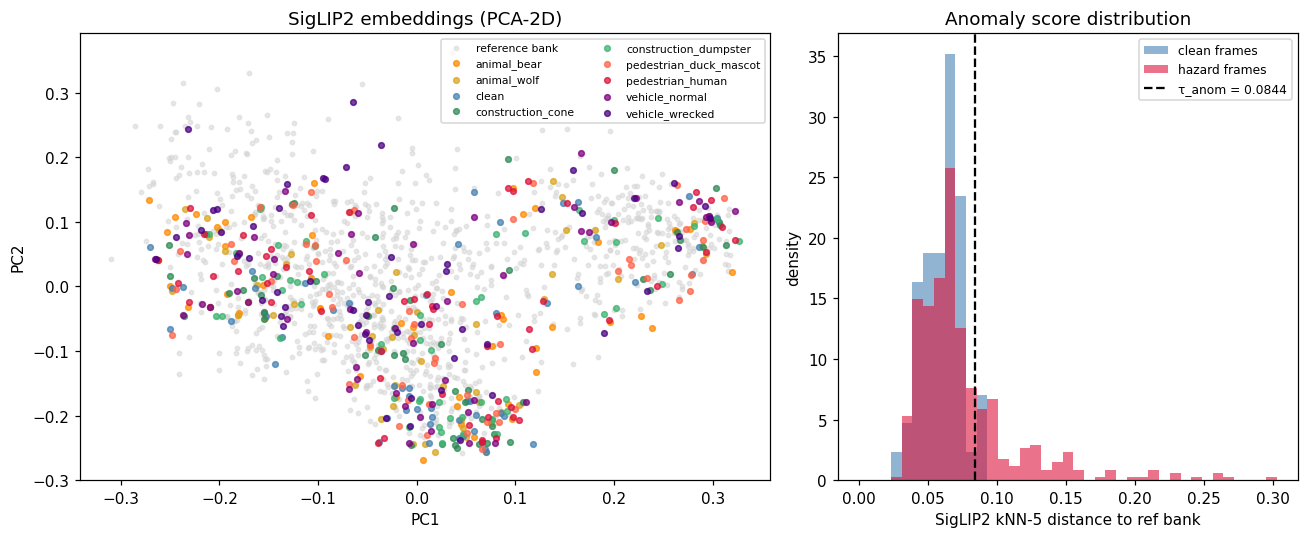

In [35]:
import numpy as np
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist

ref  = np.load('exp/anomaly_poc/ref_embeds_diverse_fwd_strip.npy').astype(np.float32)
test = np.load('exp/anomaly_poc/viz_embeds_test.npy').astype(np.float32)
meta = pd.read_csv('exp/anomaly_poc/viz_meta_test.csv')

# Anomaly score: mean cosine distance to the 5 closest reference embeddings
K = 5
dists = cdist(test, ref, metric='cosine')         # (N_test, N_ref)
knn5  = np.sort(dists, axis=1)[:, :K].mean(axis=1)
meta = meta.assign(score_knn5=knn5)

pca  = PCA(n_components=2, random_state=0)
all2d = pca.fit_transform(np.vstack([ref, test]))
ref2d, test2d = all2d[:len(ref)], all2d[len(ref):]

TAU = 0.0844      # default calibration on the synthetic benchmark clean set

case_colors = {
    'clean': 'steelblue',
    'pedestrian_human':       'crimson',     'pedestrian_duck_mascot': 'tomato',
    'animal_bear':            'darkorange',  'animal_wolf':            'goldenrod',
    'construction_cone':      'seagreen',    'construction_dumpster':  'mediumseagreen',
    'vehicle_normal':         'purple',      'vehicle_wrecked':        'indigo',
}

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios': [3, 2]})

a1.scatter(ref2d[:, 0], ref2d[:, 1], c='lightgray', s=8, alpha=0.5, label='reference bank')
for case in sorted(meta['case'].unique()):
    m = meta['case'] == case
    a1.scatter(test2d[m, 0], test2d[m, 1],
               c=case_colors.get(case, 'black'), s=14, alpha=0.75, label=case)
a1.set_xlabel('PC1'); a1.set_ylabel('PC2')
a1.set_title('SigLIP2 embeddings (PCA-2D)')
a1.legend(fontsize=7, loc='best', ncol=2)

clean_s  = meta.loc[meta['case'] == 'clean',  'score_knn5'].values
hazard_s = meta.loc[meta['case'] != 'clean', 'score_knn5'].values
bins = np.linspace(0, float(max(clean_s.max(), hazard_s.max())), 40)
a2.hist(clean_s,  bins=bins, alpha=0.6, color='steelblue', label='clean frames',  density=True)
a2.hist(hazard_s, bins=bins, alpha=0.6, color='crimson',   label='hazard frames', density=True)
a2.axvline(TAU, color='black', ls='--', label=f'τ_anom = {TAU:.4f}')
a2.set_xlabel('SigLIP2 kNN-5 distance to ref bank')
a2.set_ylabel('density')
a2.set_title('Anomaly score distribution')
a2.legend(fontsize=8)
plt.tight_layout()

## Method 2: Risk-aware VLM Scoring

On a flagged frame the VLM returns a set of hazards. Each hazard $p$ is
projected to a BEV polygon $\mathcal{P}_p$ with risk $r_p \in [0,1]$. We
score each trajectory candidate $T_i$ (from the GTRS-Dense vocabulary of
$K{=}8192$ candidates, each a sequence of 40 waypoints over 4 s) by
subtracting a soft penalty from the base score:

$$
s(T_i) \;=\; s_{\text{base}}(T_i) \;-\; \lambda \cdot r_{\text{VLM}}(T_i),
\qquad
T^{\*} = \arg\max_i s(T_i).
$$

The penalty $r_{\text{VLM}}(T_i)$ sums hazard risks weighted by how deeply
each waypoint enters a **buffered** version of the hazard region. The buffer
has two parameters:

- $H$ — ego half-width (Minkowski-inflates the polygon to account for the
  vehicle footprint),
- $R$ — soft-falloff radius beyond the inflated polygon (penalty decays
  linearly to 0 at distance $R$ from the inflated boundary).

Concretely, for waypoint $x_t$ at signed distance $d = \text{dist}(x_t, \mathcal{P}_p)$:

$$
w_t^{(p)} \;=\; \operatorname{clip}\!\left(\,1 - \frac{\max(0, d - H)}{R},\; 0,\; 1\right),
\qquad
r_{\text{VLM}}(T_i) \;=\; \sum_{p} r_p \sum_{t=1}^{40} w_t^{(p)}(T_i).
$$

With $H{=}1$ m and $R{=}5$ m, a waypoint touching the hazard polygon
contributes the full risk; one at 4 m from the inflated boundary
contributes 20%; beyond 5 m it contributes 0. Setting $\lambda{=}8$
trades smoothness of the base trajectory against hazard avoidance.

*Implementation:* `navsim/planning/script/rerank_predictions_with_vlm.py`
(see `compute_overlap_and_buffered_penalty`).

### Calling the VLM on a single anomalous frame

Once the gate flags a frame, we hand the F0 image and ego state to **Cosmos-Reason2** with a prompt that asks for hazards as 2-D bounding boxes plus a per-hazard risk in `[0, 1]`. Below is a cached response on `boston_03 / animal_bear__center` frame 82 (bear standing in the lane). The left panel is the raw F0; the right overlays the parsed bbox + label + risk; the JSON is exactly what Cosmos returned. In the cascade pipeline this output is then projected to BEV and fed to the reranker.

Parsed areas:
  - bear       risk=0.70  bbox=[919, 528, 981, 672]
    reason: The bear is standing in the middle of the road, directly in the ego vehicle's path, obstructing the planned straight movement and creating a collision risk.

ego speed_mps   = 0.48
call latency    = 1887.4726295471191 ms

Raw Cosmos response:
```json
{"detections": [{"label": "bear", "bbox": [479, 489, 511, 623], "risk": 0.7, "reason": "The bear is standing in the middle of the road, directly in the ego vehicle's path, obstructing the planned straight movement and creating a collision risk."}]}
```


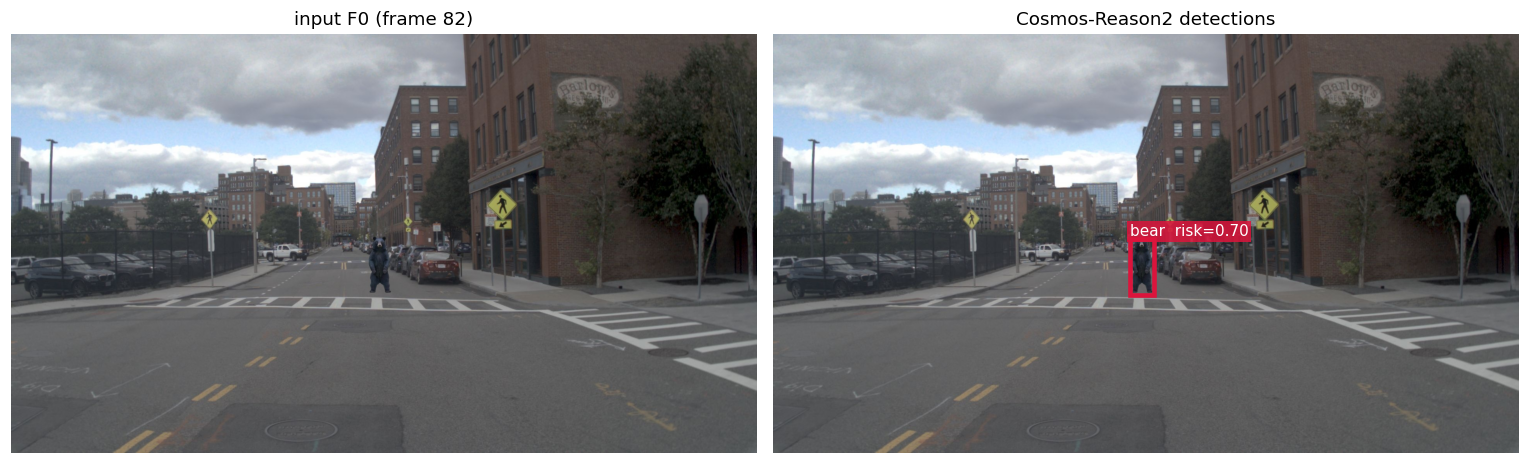

In [36]:
import json
from PIL import Image
from matplotlib.patches import Rectangle

img = Image.open('exp/viz/vlm_demo_input.jpg')
rec = json.load(open('exp/viz/vlm_demo.json'))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
a1.imshow(img); a1.axis('off'); a1.set_title('input F0 (frame 82)')
a2.imshow(img); a2.axis('off'); a2.set_title('Cosmos-Reason2 detections')
for area in rec['areas']:
    x1, y1, x2, y2 = area['bbox_pixels']
    a2.add_patch(Rectangle((x1, y1), x2-x1, y2-y1, lw=3, ec='crimson', fc='none'))
    a2.text(x1, y1 - 8,
            f"{area['label']}  risk={area['risk']:.2f}",
            color='white', fontsize=10,
            bbox=dict(facecolor='crimson', alpha=0.85, pad=2, edgecolor='none'))
plt.tight_layout()

# Parsed structure + raw response
print('Parsed areas:')
for area in rec['areas']:
    print(f"  - {area['label']:<10} risk={area['risk']:.2f}  bbox={area['bbox_pixels']}")
    print(f"    reason: {area['reason']}")
print(f"\nego speed_mps   = {rec['speed_mps']:.2f}")
print(f"call latency    = {rec.get('latency_ms', '?')} ms")
print(f"\nRaw Cosmos response:\n{rec['raw_response']}")

### Visualizing the rerank on all 8192 candidates

Left: **before** — the 8192 GTRS-Dense candidate trajectories drawn on the front camera, colored by combined log-prob score (darker = higher), with the **top-1 in red**.

Right: **after** — same candidates colored by $s_{\text{base}} - \lambda\, r_{\text{VLM}}$ with $H{=}1$ m, $R{=}5$ m, $\lambda{=}8$. Candidates whose waypoints enter the buffered hazard zone get downweighted; the new **top-1 in green** veers around the hazard.

Example: `boston_03 / animal_bear__center`, frame 82 (about one second before the bear). The bear sits in the lane ahead with risk = 0.99; 63% of the 8192 candidates incur a penalty. The base top-1 drives straight at 35 m forward / +1.6 m lateral, the new top-1 swings ~1 m to the right while extending ~10 m before slowing — a sharp avoidance.

The figure is bundled in `exp/viz/` and was rendered with the extended `scripts/scenario_synth/vocab_score_viz.py`.

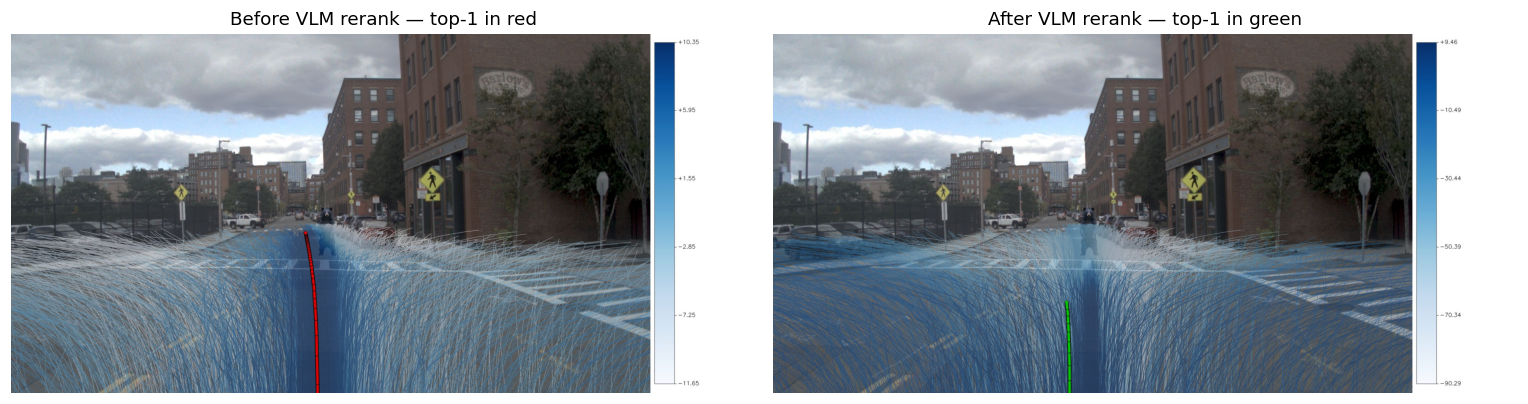

In [37]:
from PIL import Image

img_before = Image.open('exp/viz/vlm_scoring_before.jpg')
img_after  = Image.open('exp/viz/vlm_scoring_after.jpg')

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
a1.imshow(img_before); a1.axis('off')
a1.set_title('Before VLM rerank — top-1 in red')
a2.imshow(img_after);  a2.axis('off')
a2.set_title('After VLM rerank — top-1 in green')
plt.tight_layout()